In [2]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

In [25]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from pathlib import Path
from abm.model import SocialGPModel, as_batch_fixed
from abm.rewards import make_mexican_hat_reward, make_parent_and_children_correlated_dog
from abm.utils import plot_reward_grid, plot_most_common_choice_trajectory, animate_heatmap_trajectory
from abm.batch_analysis import (
    run_condition_batches,
    summarize_condition_timeseries,
    summarize_mean_reward_last_steps,
    plot_condition_comparison,
    summarize_batch_metrics,
    plot_metric_suite_by_lambda,
 )

sns.set_theme(style="whitegrid")

# Single agent simulations
This notebook shows simulations done to establish the behavior of single agents in Mexican hat environments

## 1. Sample from GPs with various priors

In [26]:
grid_size   = 11 #20
lambda_true = 2 #3

reward_params = {
    'rbf': {
        'length_scale': lambda_true
    },
    'gabor': {
        'sigma': lambda_true,
        'frequency': 1/lambda_true,
    },
    'DoG': {
        'sigma_outer': lambda_true,
        'sigma_inner': lambda_true/2
    }
}

params_lab_rotation = {
    'naito_rbf': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'gp',
        "reward_env_params": [reward_params['rbf']]
    },
    'naito_gabor': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'gabor',
        "reward_env_params": [reward_params['gabor']]
    },
    'naito_DoG': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'dog',
        "reward_env_params": [reward_params['DoG']]
    },
    'wu_rbf': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.5,
        "length_scale": lambda_true,
        "tau": 0.09,
        "alpha": 0,
        "reward_env_type": 'gp',
        "reward_env_params": [reward_params['rbf']]
    },
    'wu_gabor': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.5,
        "length_scale": lambda_true,
        "tau": 0.09,
        "alpha": 0,
        "reward_env_type": 'gabor',
        "reward_env_params": [reward_params['gabor']]
    },
    'wu_DoG': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.5,
        "length_scale": lambda_true,
        "tau": 0.09,
        "alpha": 0,
        "reward_env_type": 'dog',
        "reward_env_params": [reward_params['DoG']]
    },
}

In [13]:
n_envs         = 10
n_runs_per_env = 20
n_runs         = n_envs * n_runs_per_env
max_steps      = 150
param_set      = 'wu_DoG' 

# Create a master random number generator for reproducibility
master_rng = np.random.default_rng(1234)
env_seeds  = master_rng.integers(0, 2**63, size=n_envs, dtype=np.int64)
run_seeds  = master_rng.integers(0, 2**63, size=(n_runs_per_env), dtype=np.int64)

params_lab_rotation[param_set]["env_seed"] = env_seeds.tolist()
params_lab_rotation[param_set]["run_seed"] = run_seeds.flatten().tolist()

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params_lab_rotation[param_set],  # Change this to run different conditions
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
df_batch.to_csv('/scratch/parra/20260721_lab_rotation/wu_DoG.csv')

### 1.a Plot single runs

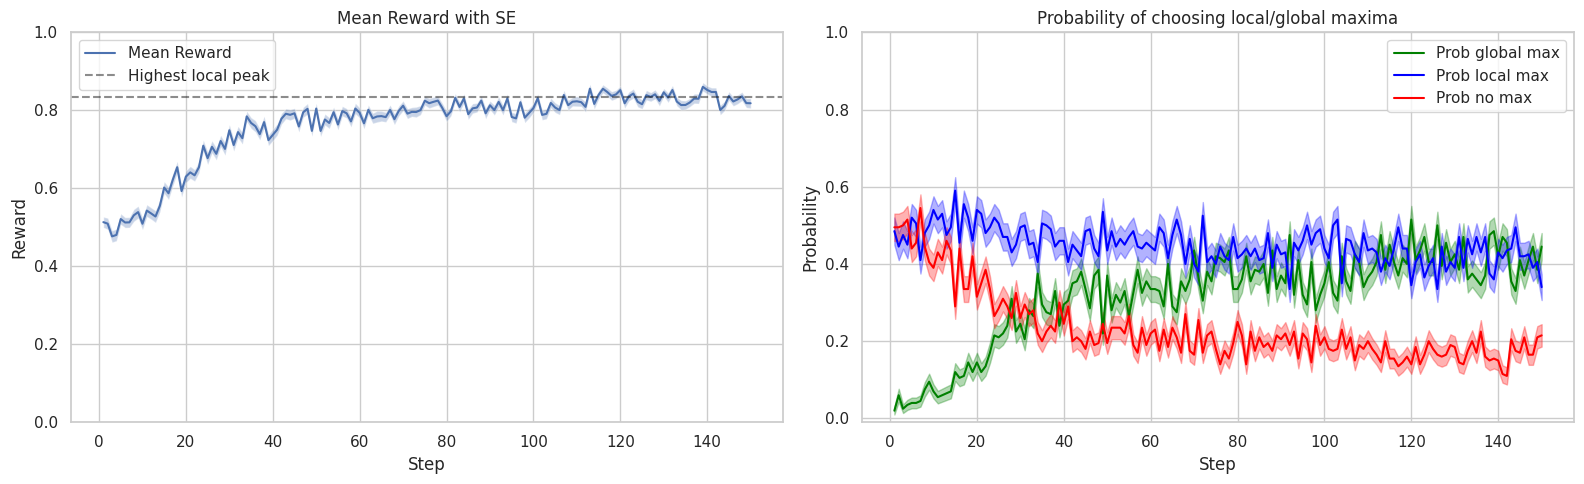

In [14]:
df_batch = pd.DataFrame(batch_results)
df_grouped = df_batch.groupby('Step').agg({
    'reward': ['mean', 'std'],
    # 'distance_to_global_peak': ['mean', 'std'],
    # 'distance_to_local_peak': ['mean', 'std'],
    'global_max': ['mean', 'std'],
    'local_max': ['mean', 'std'],
    'no_max': ['mean', 'std']
    }).reset_index()

# Plot mean reward and probabilities in adjacent subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean reward with std
reward_mean = df_grouped['reward']['mean']
reward_SE = df_grouped['reward']['std'] / np.sqrt(n_runs) 
axes[0].plot(df_grouped['Step'], reward_mean, label='Mean Reward')
axes[0].fill_between(df_grouped['Step'], reward_mean - reward_SE, reward_mean + reward_SE, alpha=0.3)
axes[0].axhline(y=1/1.2, color='k', linestyle='--', alpha=0.5, label='Highest local peak')
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: probabilities
global_max_mean = df_grouped['global_max']['mean']
global_max_SE = df_grouped['global_max']['std'] / np.sqrt(n_runs)
local_max_mean = df_grouped['local_max']['mean']
local_max_SE = df_grouped['local_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], global_max_mean, label='Prob global max', color='green')
axes[1].fill_between(df_grouped['Step'], global_max_mean - global_max_SE, global_max_mean + global_max_SE, alpha=0.3, color='green')
axes[1].plot(df_grouped['Step'], local_max_mean, label='Prob local max', color='blue')
axes[1].fill_between(df_grouped['Step'], local_max_mean - local_max_SE, local_max_mean + local_max_SE, alpha=0.3, color='blue')
not_any_max_mean = df_grouped['no_max']['mean']
not_any_max_SE = df_grouped['no_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], not_any_max_mean, label='Prob no max', color='red')
axes[1].fill_between(df_grouped['Step'], not_any_max_mean - not_any_max_SE, not_any_max_mean + not_any_max_SE, alpha=0.3, color='red')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(-0.01, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.b Plot different environment data together

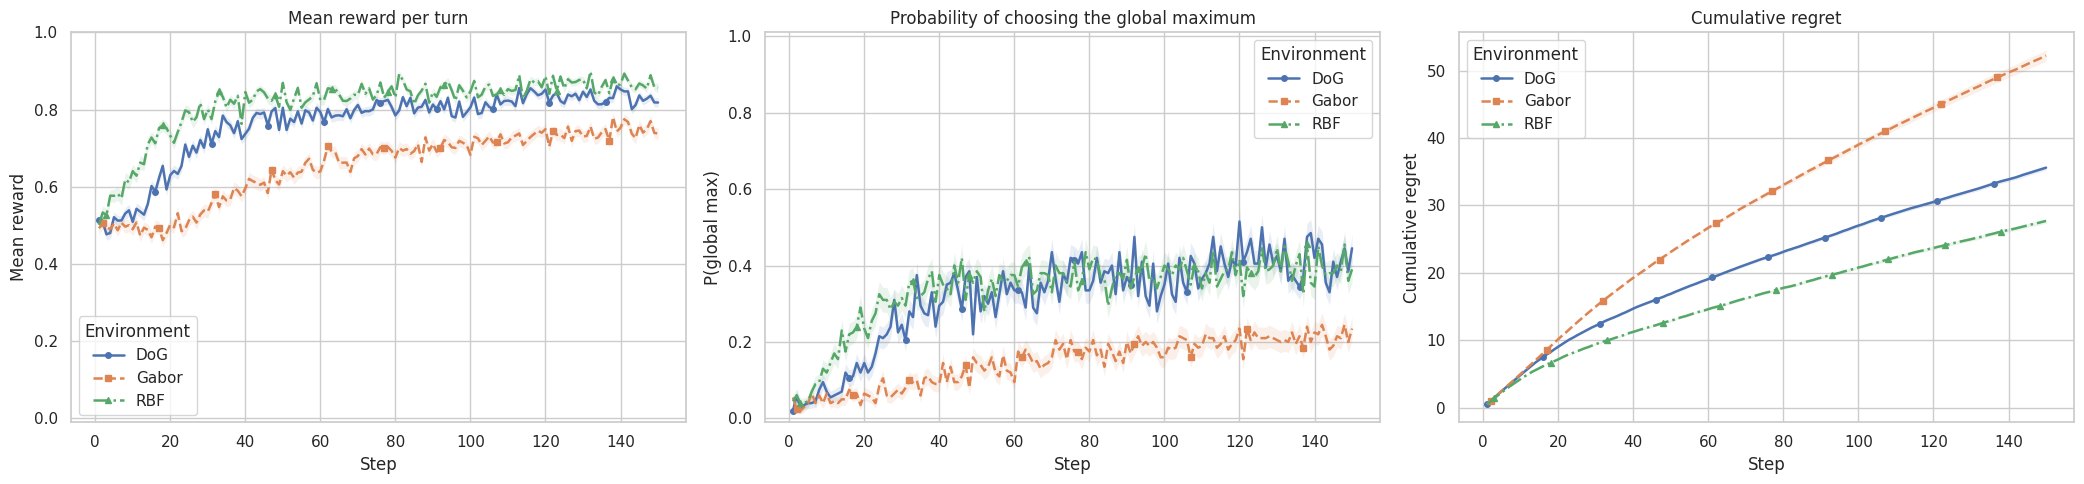

In [16]:
data_dir = Path('/scratch/parra/20260721_lab_rotation')
csv_paths = sorted(data_dir.glob('wu*.csv'))
if not csv_paths:
    raise FileNotFoundError(f'No CSV files found in {data_dir}')

csv_data = {path.stem: pd.read_csv(path) for path in csv_paths}
required_columns = {'Step', 'reward', 'global_max', 'cumulative_reward'}
for name, frame in csv_data.items():
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f'{name}.csv is missing columns: {sorted(missing)}')

fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharex=True)
labels = ['DoG','Gabor','RBF']
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D']
plotted_series = []
duplicate_series = []

for series_index, (name, frame) in enumerate(csv_data.items()):
    frame = frame.copy()
    # The optimal cumulative reward after Step turns is Step because the
    # globally best option yields a reward of 1 on every turn.
    frame['cumulative_regret'] = frame['Step'] - frame['cumulative_reward']
    summary = (
        frame.groupby('Step', sort=True)
        .agg(
            reward_mean=('reward', 'mean'),
            reward_std=('reward', 'std'),
            reward_n=('reward', 'count'),
            global_max_mean=('global_max', 'mean'),
            global_max_std=('global_max', 'std'),
            global_max_n=('global_max', 'count'),
            cumulative_regret_mean=('cumulative_regret', 'mean'),
            cumulative_regret_std=('cumulative_regret', 'std'),
            cumulative_regret_n=('cumulative_regret', 'count'),
        )
        .reset_index()
    )
    reward_se = (summary['reward_std'] / np.sqrt(summary['reward_n'])).fillna(0)
    global_max_se = (
        summary['global_max_std'] / np.sqrt(summary['global_max_n'])
    ).fillna(0)
    cumulative_regret_se = (
        summary['cumulative_regret_std']
        / np.sqrt(summary['cumulative_regret_n'])
    ).fillna(0)

    step = summary['Step'].to_numpy(dtype=float)
    reward_mean = summary['reward_mean'].to_numpy(dtype=float)
    reward_se = reward_se.to_numpy(dtype=float)
    global_max_mean = summary['global_max_mean'].to_numpy(dtype=float)
    global_max_se = global_max_se.to_numpy(dtype=float)
    cumulative_regret_mean = summary['cumulative_regret_mean'].to_numpy(dtype=float)
    cumulative_regret_se = cumulative_regret_se.to_numpy(dtype=float)

    for previous_name, previous_reward, previous_global_max in plotted_series:
        if (
            np.allclose(reward_mean, previous_reward, rtol=1e-12, atol=1e-14)
            and np.allclose(
                global_max_mean, previous_global_max, rtol=1e-12, atol=1e-14
            )
        ):
            duplicate_series.append((name, previous_name))
    plotted_series.append((name, reward_mean, global_max_mean))

    style = line_styles[series_index % len(line_styles)]
    marker = markers[series_index % len(markers)]
    marker_stride = max(1, len(step) // 10)
    marker_positions = (series_index % marker_stride, marker_stride)
    reward_line, = axes[0].plot(
        step, reward_mean, label=labels[series_index], linestyle=style, marker=marker,
        markevery=marker_positions, markersize=4, linewidth=1.8,
    )
    color = reward_line.get_color()
    axes[0].fill_between(
        step, reward_mean - reward_se, reward_mean + reward_se,
        color=color, alpha=0.12, linewidth=0,
    )
    axes[1].plot(
        step, global_max_mean, label=labels[series_index], color=color, linestyle=style,
        marker=marker, markevery=marker_positions, markersize=4, linewidth=1.8,
    )
    axes[1].fill_between(
        step,
        np.clip(global_max_mean - global_max_se, 0, 1),
        np.clip(global_max_mean + global_max_se, 0, 1),
        color=color, alpha=0.12, linewidth=0,
    )
    axes[2].plot(
        step, cumulative_regret_mean, label=labels[series_index], color=color,
        linestyle=style, marker=marker, markevery=marker_positions,
        markersize=4, linewidth=1.8,
    )
    axes[2].fill_between(
        step,
        cumulative_regret_mean - cumulative_regret_se,
        cumulative_regret_mean + cumulative_regret_se,
        color=color, alpha=0.12, linewidth=0,
    )

if duplicate_series:
    for name, previous_name in duplicate_series:
        print(
            f'Note: {name} and {previous_name} have identical plotted means; '
            'their curves overlap.'
        )

axes[0].set(
    title='Mean reward per turn', xlabel='Step', ylabel='Mean reward',
    ylim=[-0.01,1],
)
axes[1].set(
    title='Probability of choosing the global maximum',
    xlabel='Step', ylabel='P(global max)', ylim=(-0.01, 1.01),
)
axes[2].set(
    title='Cumulative regret', xlabel='Step', ylabel='Cumulative regret',
)
for ax in axes:
    ax.legend(title='Environment')

fig.tight_layout()
plt.show()


### 1.c Posterior-mean estimation error over time

For each run and turn, we average the signed error $\hat{V}(a)-V(a)$ across all arms. Each box summarizes that run-level mean across the 200 runs. Positive values indicate overestimation and negative values indicate underestimation.

In [20]:
from copy import deepcopy

error_conditions = {
    'RBF': 'naito_rbf',
    'Gabor': 'naito_gabor',
    'DoG': 'naito_DoG',
}
error_n_envs = 10
error_n_runs_per_env = 20
error_max_steps = 300

# Reuse identical environment and behavioral seeds for every prior. Mesa
# takes the Cartesian product, giving 10 * 20 = 200 runs per condition.
error_master_rng = np.random.default_rng(1234)
error_env_seeds = error_master_rng.integers(
    0, 2**63, size=error_n_envs, dtype=np.int64,
).tolist()
error_run_seeds = error_master_rng.integers(
    0, 2**63, size=error_n_runs_per_env, dtype=np.int64,
).tolist()

error_frames = []
for condition_label, parameter_key in error_conditions.items():
    condition_parameters = deepcopy(params_lab_rotation[parameter_key])
    condition_parameters['env_seed'] = error_env_seeds
    condition_parameters['run_seed'] = error_run_seeds
    condition_parameters['agent_reporters_to_collect'] = as_batch_fixed(
        ['posterior_mean_error', 'mean_posterior_variance']
    )

    condition_results = mesa.batch_run(
        SocialGPModel,
        parameters=condition_parameters,
        max_steps=error_max_steps,
        display_progress=True,
        data_collection_period=1,
        number_processes=None,
    )
    condition_frame = pd.DataFrame(condition_results)
    condition_frame['condition'] = condition_label
    error_frames.append(
        condition_frame[[
            'condition', 'RunId', 'iteration', 'Step', 'AgentID',
            'env_seed', 'run_seed', 'posterior_mean_error',
            'mean_posterior_variance',
        ]]
    )

estimation_error_df = pd.concat(error_frames, ignore_index=True)


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [29]:
# estimation_error_df.to_csv(
#     '/scratch/parra/20260721_lab_rotation/posterior_estimation_error_naito_300.csv',
#     index=False,
# )

estimation_error_df = pd.read_csv(
    '/scratch/parra/20260721_lab_rotation/posterior_estimation_error_naito_300.csv',
)

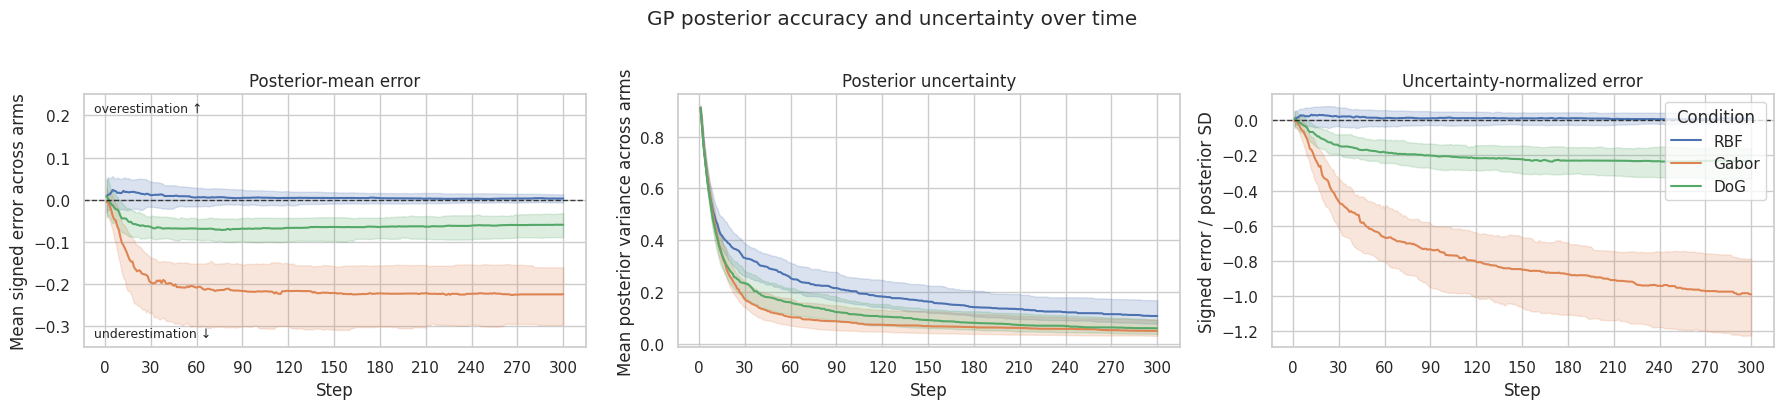

In [30]:
plot_data = estimation_error_df.assign(
    normalized_posterior_mean_error=lambda df: (
        df['posterior_mean_error'] / np.sqrt(df['mean_posterior_variance'])
    )
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
condition_colors = dict(zip(error_conditions, sns.color_palette(n_colors=3)))
sns.lineplot(
    data=plot_data, x='Step', y='posterior_mean_error',
    hue='condition', hue_order=error_conditions, palette=condition_colors,
    estimator='median', errorbar=('pi', 50), linewidth=1.5, ax=axes[0],
    legend=False,
)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Mean signed error across arms')
axes[0].set_title('Posterior-mean error')
axes[0].text(
        0.02, 0.97, 'overestimation \u2191', transform=axes[0].transAxes,
        ha='left', va='top', fontsize=9,
    )
axes[0].text(
        0.02, 0.03, 'underestimation \u2193', transform=axes[0].transAxes,
        ha='left', va='bottom', fontsize=9,
    )
tick_positions = np.arange(0, error_max_steps + 1, 30)
axes[0].set_ylim([-0.35, 0.25])
axes[0].set_xticks(tick_positions)

sns.lineplot(
    data=plot_data, x='Step', y='mean_posterior_variance',
    hue='condition', hue_order=error_conditions, palette=condition_colors,
    estimator='median', errorbar=('pi', 50), linewidth=1.5, ax=axes[1],
    legend=False,
)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Mean posterior variance across arms')
axes[1].set_title('Posterior uncertainty')
axes[1].set_xticks(tick_positions)

sns.lineplot(
    data=plot_data, x='Step', y='normalized_posterior_mean_error',
    hue='condition', hue_order=error_conditions, palette=condition_colors,
    estimator='median', errorbar=('pi', 50), linewidth=1.5, ax=axes[2],
)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Signed error / posterior SD')
axes[2].set_title('Uncertainty-normalized error')
axes[2].set_xticks(tick_positions)
axes[2].legend(title='Condition', loc='upper right')

fig.suptitle('GP posterior accuracy and uncertainty over time', y=1.02)
fig.tight_layout()
plt.show()

## 2. Simple environments directly from kernels

In [4]:
grid_size   = 11 #20
lambda_true = 2 #3

# Naito: lambda = 1.86 vs true of 1.5
naito_lambda_ratio = 1.86 / 1.5
giron_lambda_ratio = 0.43 / 4

# Define reward parameters for Mexican Hat GP environment
reward_params = {
    'length_scale': lambda_true,
    # 'target_correlation': 1.0
}

In [6]:
# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params]
    },
    'giron_5-8': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.53,
        "length_scale": lambda_true*giron_lambda_ratio,
        "tau": 0.02,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_o_naito': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_o_low_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.01,
        "length_scale": lambda_true,
        "tau": 0.01,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_o_high_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.5,
        "length_scale": lambda_true,
        "tau": 0.1,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_i_naito': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.19,
        "length_scale": lambda_true/2.0,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_i_high_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.5,
        "length_scale": lambda_true/2.0,
        "tau": 0.1,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params]
    },
    'lambda_is_sigma_i_low_random': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.01,
        "length_scale": lambda_true/2.0,
        "tau": 0.01,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
        "agent_reporters_to_collect": ["distance_to_global_peak", "distance_to_local_peak", "reward"]
    },
    'optimal_P_global_max_500steps': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.675,
        "length_scale": lambda_true/2.0,
        "tau": 0.012,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
    },
    'optimal_cum_reward_500steps': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.6,
        "length_scale": lambda_true/2.0,
        "tau": 0.015,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
    },
    'optimal_cum_reward_20steps': {
        "n": 1,
        "grid_size": grid_size,
        "beta": 0.125,
        "length_scale": lambda_true,
        "tau": 0.012,
        "alpha": 0,
        "reward_env_type": 'mexican_hat_gp',
        "reward_env_params": [reward_params],
    }
}

In [6]:
n_envs         = 10
n_runs_per_env = 20
n_runs         = n_envs * n_runs_per_env
max_steps      = 50
param_set      = 'naito_gabor' # 'optimal_cum_reward_20steps' # 'lambda_is_sigma_o_low_random'

# Create a master random number generator for reproducibility
master_rng = np.random.default_rng(1234)
env_seeds  = master_rng.integers(0, 2**63, size=n_envs, dtype=np.int64)
run_seeds  = master_rng.integers(0, 2**63, size=(n_runs_per_env), dtype=np.int64)

params_lab_rotation[param_set]["env_seed"] = env_seeds.tolist()
params_lab_rotation[param_set]["run_seed"] = run_seeds.flatten().tolist()

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params_lab_rotation[param_set],  # Change this to run different conditions
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/200 [00:00<?, ?it/s]

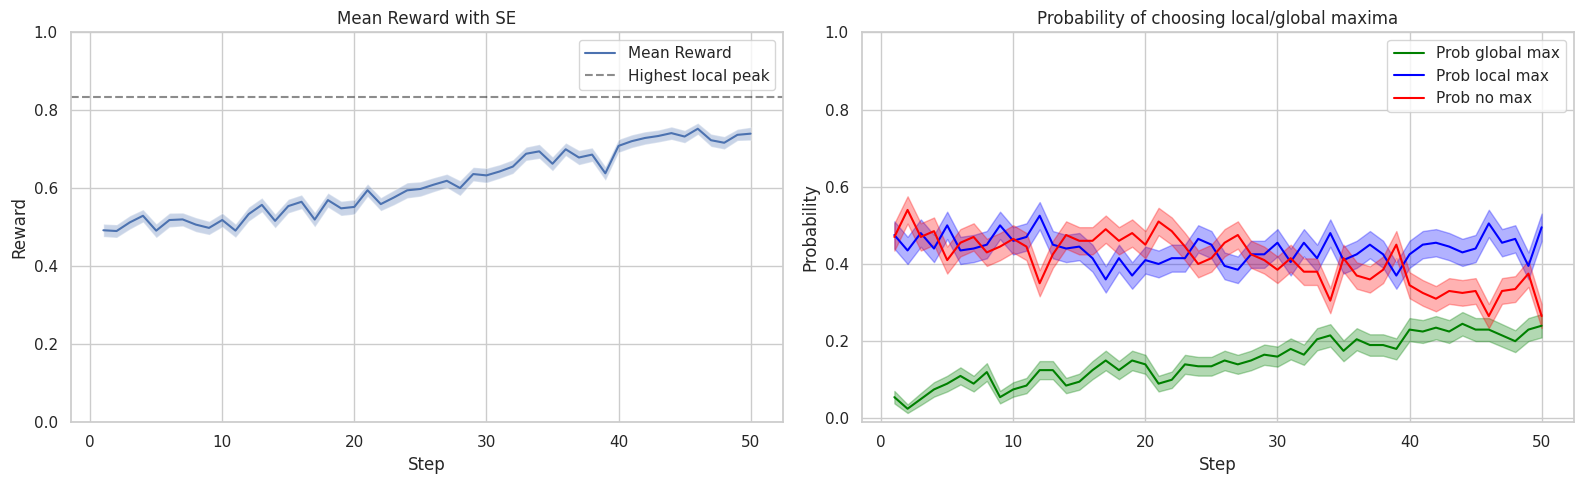

In [7]:
df_batch = pd.DataFrame(batch_results)
df_grouped = df_batch.groupby('Step').agg({
    'reward': ['mean', 'std'],
    # 'distance_to_global_peak': ['mean', 'std'],
    # 'distance_to_local_peak': ['mean', 'std'],
    'global_max': ['mean', 'std'],
    'local_max': ['mean', 'std'],
    'no_max': ['mean', 'std']
    }).reset_index()

# Plot mean reward and probabilities in adjacent subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean reward with std
reward_mean = df_grouped['reward']['mean']
reward_SE = df_grouped['reward']['std'] / np.sqrt(n_runs) 
axes[0].plot(df_grouped['Step'], reward_mean, label='Mean Reward')
axes[0].fill_between(df_grouped['Step'], reward_mean - reward_SE, reward_mean + reward_SE, alpha=0.3)
axes[0].axhline(y=1/1.2, color='k', linestyle='--', alpha=0.5, label='Highest local peak')
axes[0].set_title('Mean Reward with SE')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: probabilities
global_max_mean = df_grouped['global_max']['mean']
global_max_SE = df_grouped['global_max']['std'] / np.sqrt(n_runs)
local_max_mean = df_grouped['local_max']['mean']
local_max_SE = df_grouped['local_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], global_max_mean, label='Prob global max', color='green')
axes[1].fill_between(df_grouped['Step'], global_max_mean - global_max_SE, global_max_mean + global_max_SE, alpha=0.3, color='green')
axes[1].plot(df_grouped['Step'], local_max_mean, label='Prob local max', color='blue')
axes[1].fill_between(df_grouped['Step'], local_max_mean - local_max_SE, local_max_mean + local_max_SE, alpha=0.3, color='blue')
not_any_max_mean = df_grouped['no_max']['mean']
not_any_max_SE = df_grouped['no_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], not_any_max_mean, label='Prob no max', color='red')
axes[1].fill_between(df_grouped['Step'], not_any_max_mean - not_any_max_SE, not_any_max_mean + not_any_max_SE, alpha=0.3, color='red')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(-0.01, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.c Compare all parameter combinations
Run all entries in `params` and compare trajectories across conditions for cumulative reward, mean reward, and max-state probabilities.

In [ ]:
batches = ['naito', 'lambda_is_sigma_i_naito', 'lambda_is_sigma_o_naito']
comparison_parameter_sets = {
    condition_name: {
        **condition_parameters,
        "model_reporters_to_collect": ["mean_reward"],
        "agent_reporters_to_collect": [
            "reward",
            "cumulative_reward",
            "global_max",
            "local_max",
            "no_max",
            "distance_to_global_peak",
            "distance_to_local_peak",
        ],
    }
    for condition_name, condition_parameters in params.items()
    if condition_name in batches
}

n_runs = 10
max_steps = 30
comparison_results = run_condition_batches(
    model_cls=SocialGPModel,
    parameter_sets=comparison_parameter_sets,
    n_runs=n_runs,
    max_steps=max_steps,
    data_collection_period=1,
    number_processes=None,
    display_progress=True,
    rng_values=[None] * n_runs,
 )

comparison_summary = summarize_condition_timeseries(comparison_results)
mean_reward_last_5 = summarize_mean_reward_last_steps(
    comparison_results,
    window_size=5,
    reward_col='reward',
    step_col='Step',
    condition_col='condition',
)

comparison_summary.head(), mean_reward_last_5

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,condition,Step,cumulative_reward,reward,global_max,local_max,no_max
0,lambda_is_sigma_i_naito,5.0,2.528278,0.607655,0.1,0.5,0.4
1,lambda_is_sigma_i_naito,10.0,5.369431,0.537283,0.0,0.1,0.9
2,lambda_is_sigma_i_naito,15.0,8.461542,0.641554,0.0,0.1,0.9
3,lambda_is_sigma_i_naito,20.0,11.346851,0.617270,0.0,0.2,0.8
4,lambda_is_sigma_i_naito,25.0,14.343830,0.601240,0.1,0.0,0.9


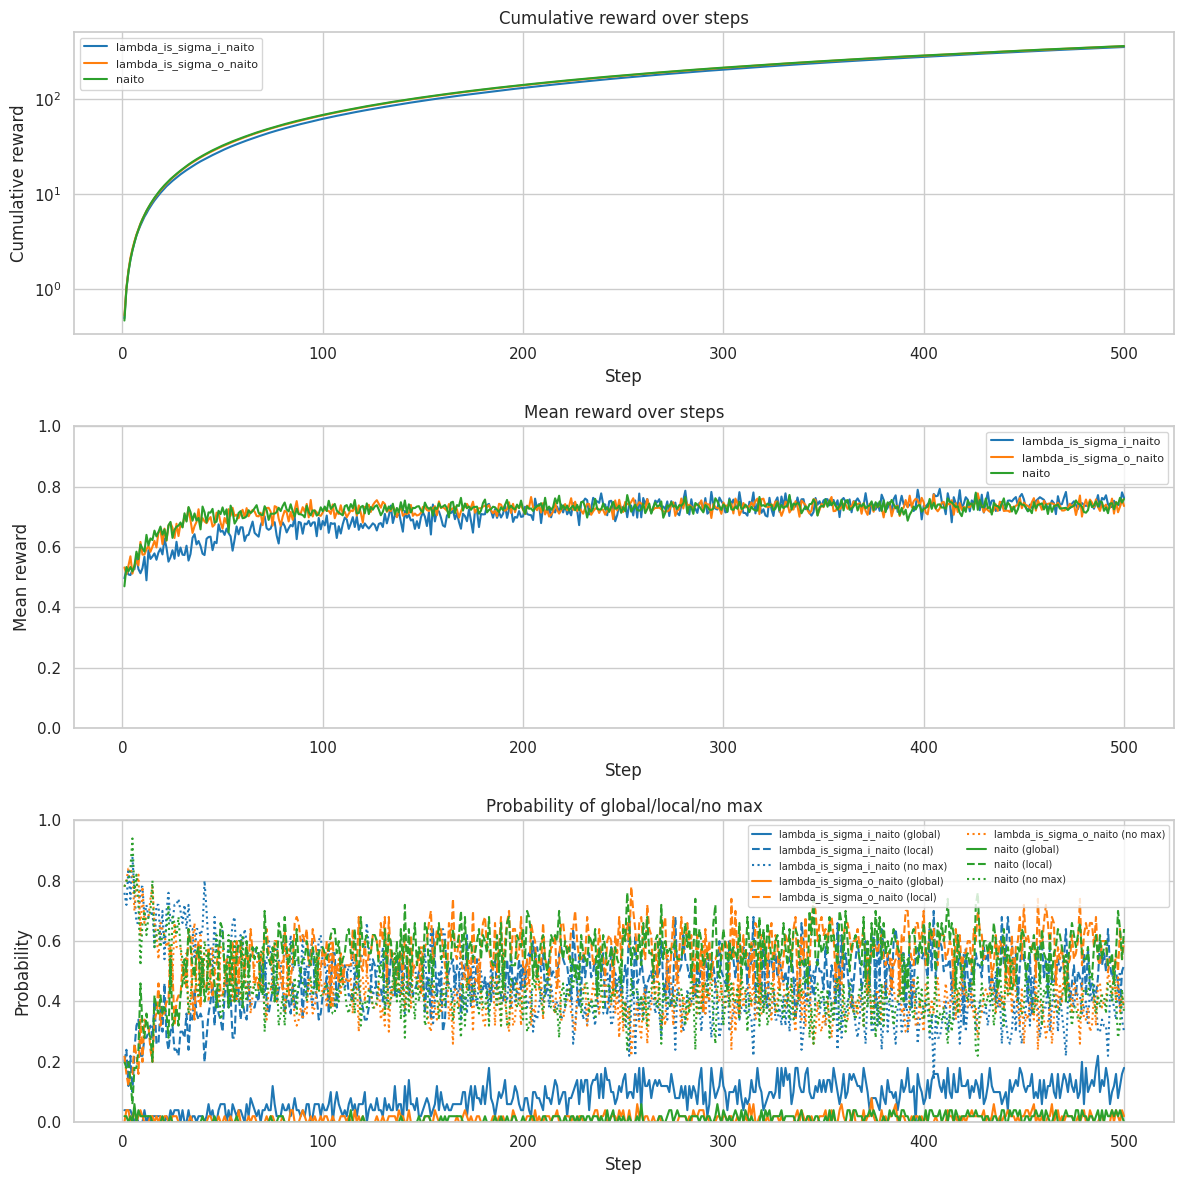

In [22]:
plot_condition_comparison(comparison_summary)
plt.show()

### 2.d Analyze sample individual

In [15]:
seed = 24
rng  = np.random.default_rng(seed)

grid_size   = 33
lambda_true = 4.5
n_runs      = 1
max_steps   = 30
# Naito: lambda = 1.86 vs true of 1.5
naito_lambda_ratio = 1.86 / 1.5

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9
}

# Sets of parameters for different conditions to be tested in the batch run
params = {
    'naito': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.19,
        "length_scale": lambda_true*naito_lambda_ratio,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_true_low_random': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.01,
        "length_scale": lambda_true,
        "tau": 0.01,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_true_high_random': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.5,
        "length_scale": lambda_true,
        "tau": 0.1,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    },
    'lambda_inner_naito': {
        "n": 1,
        "grid_size": grid_size,
        "rng": rng,
        "beta": 0.19,
        "length_scale": lambda_true/2.0,
        "tau": 0.07,
        "alpha": 0,
        "reward_env_type": 'corr_dog',
        "reward_env_params": [reward_params]
    }
}

In [16]:
batch_results = mesa.batch_run(
    SocialGPModel,
    rng=[rng]*n_runs,
    parameters=params['lambda_inner_naito'],
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=1,
    number_processes=None,
)

  0%|          | 0/1 [00:00<?, ?it/s]

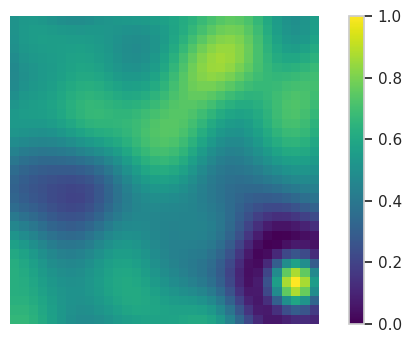

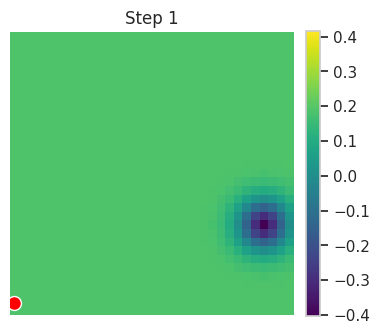

In [17]:
rng = np.random.default_rng(seed)
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9,
    'n_children': 1
}

_, reward, _ = make_parent_and_children_correlated_dog(
    rng=rng,
    grid_size=grid_size,
    **reward_params
)
plot_reward_grid(reward[0])
plt.show()

df_batch = pd.DataFrame(batch_results)
ani, fig, ax = animate_heatmap_trajectory(
    df_batch,
    heatmap_col='value',
    choice_col='choice',
    save_path='policy_evolution.gif',
    fps=3,
    start_idx=1,
    repeat=False,
    title_prefix='Step',
)

## 3. Sweep parameters
For small batches/few parameter configurations, can execute the cell below (may take about an hour).

For larger parameter sweeps, use ```run_parameter_sweep.sh``` to run a slurm batch. Usage:
- in home/\<user\>/Spatial-MAB-taboo: ``` sbatch --export=ALL,OUTPUT_DIR=/scratch/<user>/results run_parameter_sweep.sh``` 
- By default, results will be saved to scratch/\<user\>/parameter_sweep.csv

In [ ]:
grid_size = 33
lambda_true = 4.5
n_runs    = 50
max_steps = 300

# Naito: lambda = 1.86 vs true of 1.5
naito_lambda_ratio = 1.86 / 1.5

# Define reward parameters for the correlated DoG environment
reward_params = {
    'length_scale': lambda_true,
    'target_correlation': 0.9,
}

params = {
    "n": 1,
    "grid_size": grid_size,
    "beta": np.arange(0, 0.51, 0.025),
    "length_scale": lambda_true * np.array([0.5, 1.0, 2.0]),
    "tau": np.array([0.005]) + np.arange(0.01, 0.11, 0.01),
    "alpha": 0,
    "reward_env_type": 'corr_dog',
    "reward_env_params": [reward_params],
    "collect_agent_reporters": True,
    "model_reporters_to_collect": [["mean_cumulative_reward"]],
    "agent_reporters_to_collect": [["distance_to_global_peak", "distance_to_local_peak", "reward"]],
}

batch_results = mesa.batch_run(
    SocialGPModel,
    parameters=params,
    max_steps=max_steps,
    display_progress=True,
    data_collection_period=-1,
    number_processes=None,
    rng=[None] * n_runs,
 )

df_batch = pd.DataFrame(batch_results)
df_batch.to_csv('parameter_sweep_corr_dog.csv', index=False)

In [4]:
# Merge all CSVs in given folder to a single dataframe
import os
import glob

all_files = glob.glob(os.path.join('/scratch/parra/monadic300_2', "*.csv"))
df_list = []
for file in all_files:
    df = pd.read_csv(file)
    df_list.append(df)
merged_df = pd.concat(df_list, ignore_index=True)

In [9]:
merged_df = merged_df[merged_df['tau'] == 0.03]

In [14]:
# load /scratch/parra/parameter_sweeps/[job].csv 
df_combined = pd.read_csv('parameter_sweep_monadic300_tau_03_stacked.csv')

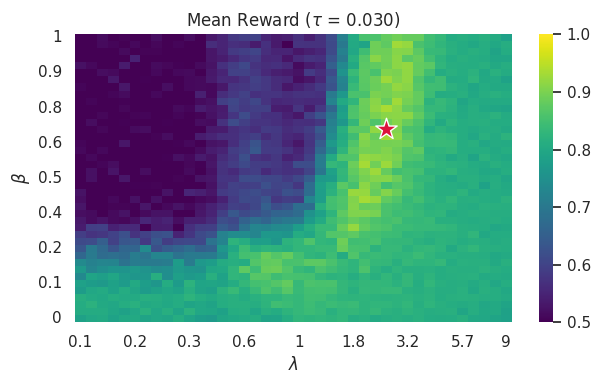

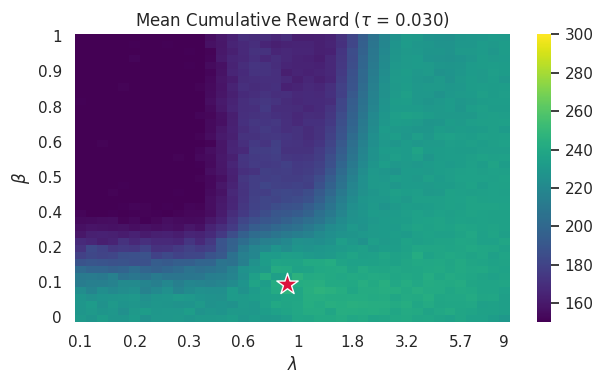

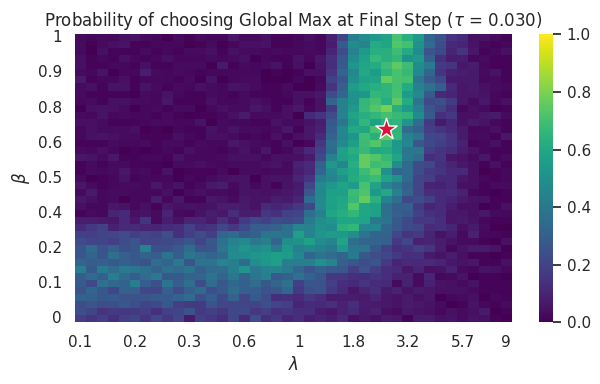

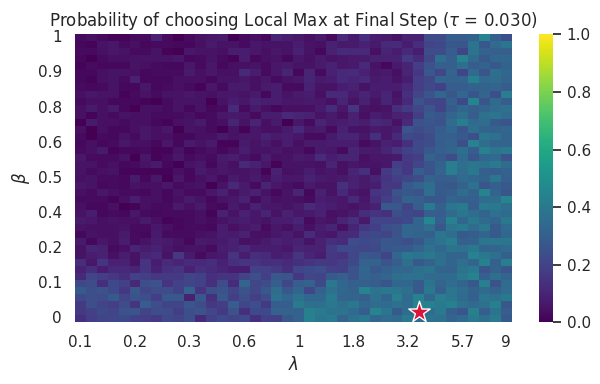

[(<Figure size 1200x400 with 3 Axes>,
  array([[<Axes: title={'center': 'Mean Reward ($\\tau$ = 0.030)'}, xlabel='$\\lambda$', ylabel='$\\beta$'>,
          <Axes: >]], dtype=object)),
 (<Figure size 1200x400 with 3 Axes>,
  array([[<Axes: title={'center': 'Mean Cumulative Reward ($\\tau$ = 0.030)'}, xlabel='$\\lambda$', ylabel='$\\beta$'>,
          <Axes: >]], dtype=object)),
 (<Figure size 1200x400 with 3 Axes>,
  array([[<Axes: title={'center': 'Probability of choosing Global Max at Final Step ($\\tau$ = 0.030)'}, xlabel='$\\lambda$', ylabel='$\\beta$'>,
          <Axes: >]], dtype=object)),
 (<Figure size 1200x400 with 3 Axes>,
  array([[<Axes: title={'center': 'Probability of choosing Local Max at Final Step ($\\tau$ = 0.030)'}, xlabel='$\\lambda$', ylabel='$\\beta$'>,
          <Axes: >]], dtype=object))]

In [20]:
metric_specs = [
    {
        'column': 'reward',
        'label': 'Mean Reward',
        'fmt': '.2f',
        'vmin': 0.5,
        'vmax': 1.0,
        'cbar_label': ''
    },
    {
        'column': 'mean_cumulative_reward',
        'label': 'Mean Cumulative Reward',
        'fmt': '.1f',
        'vmin': 150,
        'vmax': 300,
        'cbar_label': ''

    },
    {
        'column': 'global_max',
        'label': 'Probability of choosing Global Max at Final Step',
        'fmt': '.2f',
        'vmin': 0,
        'vmax': 1,
        'cbar_label': ''
    },
    {
        'column': 'local_max',
        'label': 'Probability of choosing Local Max at Final Step',
        'fmt': '.2f',
        'vmin': 0,
        'vmax': 1,
        'cbar_label': ''
    },
]

summary_df = summarize_batch_metrics(
    df_combined,
    metric_columns=[spec['column'] for spec in metric_specs],
    group_columns=('beta', 'length_scale', 'tau'),
)

plot_metric_suite_by_lambda(
    summary_df=summary_df,
    metric_specs=metric_specs,
    cmap='viridis',
    ncols=2,
    subplot_size=(6, 4),
    max_x_ticks=9,
    max_y_ticks=9,
    y_descending=True,
    panel_column='tau',
    x_column='length_scale',
    y_column='beta',
)

## 4. Study dynamics of optimal parameters

In [5]:
import os
import glob


def optimal_parameters_by_step(
    csv_folder,
    maximize_col,
    param_columns=None,
    fixed_params=None,
    step_col="Step",
    chunksize=100000,
    sort_ascending=False,
):
    """Return the best parameter set at each step for a given sweep metric.

    The function reads CSV files from `csv_folder` in streaming chunks,
    filters rows by any fixed parameter values, aggregates the target metric
    by step and the remaining free parameter combination, and returns the
    best combination per step based on the mean value of `maximize_col`.

    Parameters
    ----------
    csv_folder : str
        Path to the folder containing sweep CSV files.
    maximize_col : str
        Column name to maximize (for example, 'global_max' or 'mean_cumulative_reward').
    param_columns : list[str], optional
        Columns that identify the free parameter combinations. If None, the
        function will attempt to infer constant columns from the first CSV file.
    fixed_params : dict[str, object], optional
        Parameter values that should be held fixed when selecting the best
        combination. These columns are filtered before maximizing.
    step_col : str, default 'Step'
        Column name for the step index.
    chunksize : int, default 100000
        Number of rows to read per chunk.
    sort_ascending : bool, default False
        If True, returns the smallest values instead of the largest.

    Returns
    -------
    pandas.DataFrame
        One row per step with the best parameter values and the mean target value.
    """
    csv_paths = sorted(glob.glob(os.path.join(csv_folder, "*.csv")))
    if not csv_paths:
        raise ValueError(f"No CSV files found in folder: {csv_folder}")

    fixed_params = fixed_params or {}
    if not isinstance(fixed_params, dict):
        raise ValueError("fixed_params must be a dict of parameter names to values.")

    if param_columns is None:
        sample = pd.read_csv(csv_paths[0], nrows=1000)
        if step_col not in sample.columns or maximize_col not in sample.columns:
            raise ValueError(
                f"Columns {step_col!r} and {maximize_col!r} must exist in the sweep CSVs"
            )
        candidate_columns = [
            c for c in sample.columns if c not in {step_col, maximize_col}
        ]
        candidate_columns = [c for c in candidate_columns if c not in fixed_params]
        constant_columns = [
            c for c in candidate_columns if sample[c].nunique(dropna=False) == 1
        ]
        if not constant_columns:
            raise ValueError(
                "Could not infer parameter columns from the sample file; please pass param_columns explicitly."
            )
        param_columns = constant_columns

    if not isinstance(param_columns, (list, tuple)):
        param_columns = [param_columns]

    usecols = [step_col, maximize_col] + list(param_columns) + list(fixed_params.keys())
    aggregator = {}
    for csv_path in csv_paths:
        for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunksize):
            chunk = chunk.dropna(subset=[step_col, maximize_col])
            for name, value in fixed_params.items():
                if name not in chunk.columns:
                    raise ValueError(f"Fixed parameter column {name!r} not found in CSV file: {csv_path}")
                chunk = chunk[chunk[name] == value]
            if chunk.empty:
                continue

            grouped = (
                chunk.groupby([step_col] + list(param_columns), dropna=False, as_index=False)[maximize_col]
                .agg(sum_value="sum", count_value="count")
            )
            for record in grouped.to_dict(orient="records"):
                step = record[step_col]
                param_vals = tuple(record[col] for col in param_columns)
                key = (step, param_vals)
                stats = aggregator.setdefault(key, {"sum": 0.0, "count": 0})
                stats["sum"] += record["sum_value"]
                stats["count"] += record["count_value"]

    if not aggregator:
        raise ValueError("No valid rows found in the CSV files.")

    rows = []
    for (step, param_vals), stats in aggregator.items():
        rows.append(
            {
                step_col: step,
                **{param_columns[i]: param_vals[i] for i in range(len(param_columns))},
                **fixed_params,
                f"mean_{maximize_col}": stats["sum"] / stats["count"],
                "n_rows": stats["count"],
            }
        )

    best_df = (
        pd.DataFrame(rows)
        .sort_values([step_col, f"mean_{maximize_col}"], ascending=[True, sort_ascending])
        .groupby(step_col, as_index=False)
        .first()
        .sort_values(step_col)
        .reset_index(drop=True)
    )

    return best_df

In [ ]:
best_by_step = optimal_parameters_by_step(
    csv_folder='/scratch/parra/monadic300',
    maximize_col='mean_cumulative_reward',
    param_columns=['beta', 'length_scale', 'tau'],
    fixed_params={'tau': 0.03},
)


# save best_by_step to csv
best_by_step.to_csv('../parameter_sweeps/monadic_300_best_params_by_step_for_cum_reward_tau_03.csv', index=False)


In [3]:
best_by_step = pd.read_csv('../parameter_sweeps/monadic_300_best_params_by_step_for_cum_reward_tau_03.csv')
best_by_step.head()

,Step,beta,length_scale,tau,mean_reward,n_rows
0,1.0,0.775,0.710967,0.03,0.553265,100
1,2.0,0.000,1.420699,0.03,0.578154,100
2,3.0,0.050,2.529565,0.03,0.605761,100
3,4.0,0.075,6.366726,0.03,0.639887,100
4,5.0,0.025,5.054737,0.03,0.663709,100


/home/parra/Spatial-MAB-taboo/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/parra/Spatial-MAB-taboo/.venv/lib/python3.13/site-packages/mpl_toolkits/mplot3d/proj3d.py:148: RuntimeWarning: invalid value encountered in dot
  vecw = np.dot(M, vec.data)
/home/parra/Spatial-MAB-taboo/.venv/lib/python3.13/site-packages/mpl_toolkits/mplot3d/proj3d.py:150: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0] / w, vecw[1] / w, vecw[2] / w


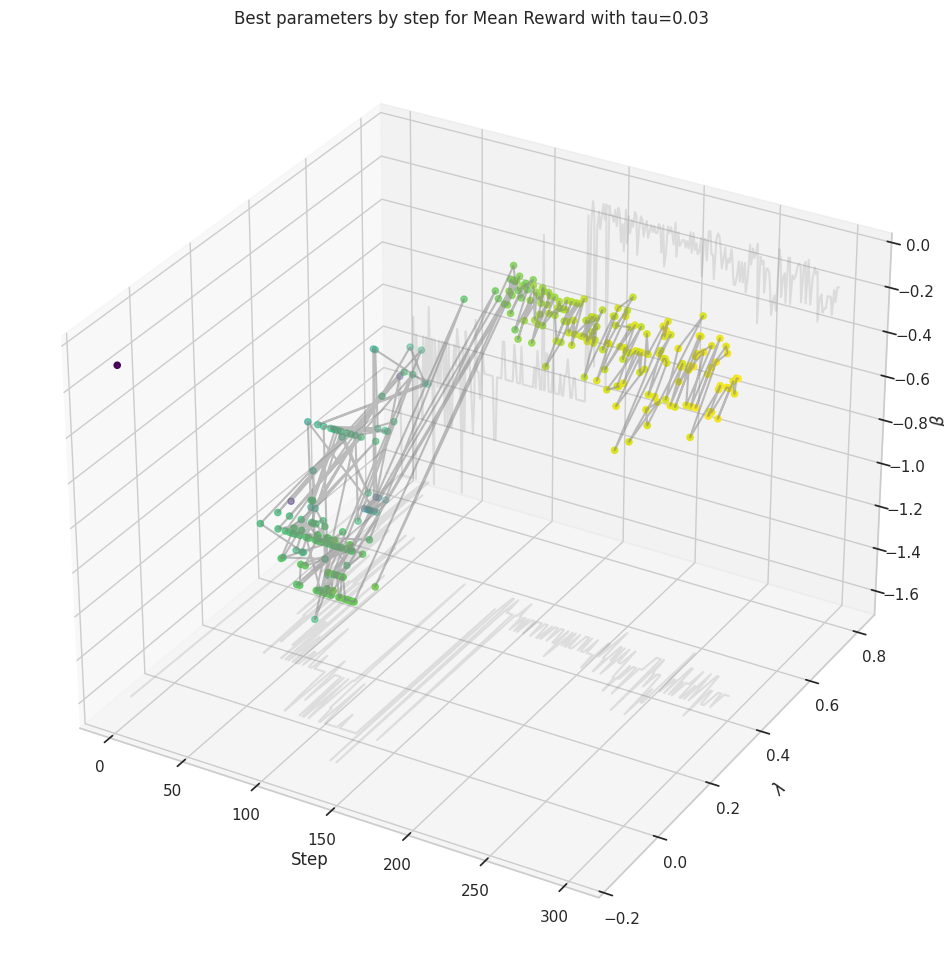

In [20]:
x = best_by_step['Step']
y = np.log10(best_by_step['length_scale'])
z = np.log10(best_by_step['beta'])
c = best_by_step['mean_reward']

# plot best_by_step with Step on x axis, lambda on y axis, beta on z axis, and color by mean_cumulative_reward
plt.figure(figsize=(12,12))
ax = plt.axes(projection='3d')
ax.plot3D(
    x,
    y,
    z,
    color='gray',
    alpha=0.5,
)
ax.scatter3D(
    x,
    y,
    z,
    c=c,
    cmap='viridis',
    s=20,
)
ax.set_xlabel('Step')
ax.set_ylabel(r'$\lambda$')
ax.set_zlabel(r'$\beta$')

# add 2d projection of xy plane
ax.plot3D(
    x,
    y,
    zs=-1.6,
    zdir='z',
    color='gray',
    alpha=0.2,
)
# add 2d projection of xz plane onto wall at max of y
ax.plot3D(
    x,
    y.max(),
    zs=z,
    zdir='z',
    color='gray',
    alpha=0.2,
)


plt.title('Best parameters by step for Mean Reward with tau=0.03')
plt.show()